In [94]:
# Steps -> Imports -> Dataloader -> transformation 

import os
import shutil
import random
import torch
import torchvision.transforms.v2 as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import datasets
import torch.nn as nn
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score
from torch.utils.tensorboard import SummaryWriter
import torchvision.models as models

In [95]:
# Applying CutMix and MixUp

# transforms.RandomChoice works like a selector switch. 
# It takes a list of different transformations you give it, and every time a new batch passes through, 
# it randomly picks exactly one transformation from that list to apply, discarding the others for that turn.
# returns -> advanced_batch_augment(images, labels)
def apply_cut_mix_up():
    mixup = transforms.MixUp(alpha=0.2, num_classes=2) 
    cutmix = transforms.CutMix(alpha=1.0, num_classes=2)
    mix_choice = transforms.RandomChoice([mixup, cutmix])

    # Set probability to 50% so the model sees both clean and blended images
    return transforms.RandomApply([mix_choice], p=0.5)


def train_epoch(model, train_loader, optimizer, criterion, epoch, device, advanced_batch_augment=None):
    loss_list = []
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        
        # =====================================================================
        # ADVANCED BATCH AUGMENTATION
        # =====================================================================
        # Apply CutMix or MixUp to the batch if the augmentation function is provided
        if advanced_batch_augment is not None:
            images, labels = advanced_batch_augment(images, labels)
        # =====================================================================
        
        # Clear gradients w.r.t. parameters
        optimizer.zero_grad()
         
        # Forward pass to get output/logits
        outputs = model(images)
         
        # Calculate Loss (Handles both integer labels and soft probability matrices)
        loss = criterion(outputs, labels)
        loss_list.append(loss.item())
         
        # Getting gradients w.r.t. parameters
        loss.backward()
         
        # Updating parameters
        optimizer.step()
        
    mean_loss = np.mean(loss_list)
    return mean_loss, loss_list


@torch.no_grad()
def eval_model(model, eval_loader, criterion, device):
    """ Evaluating the model for either validation or test (Strictly Clean Data) """
    correct = 0
    total = 0
    loss_list = []
    
    for images, labels in eval_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass only to get logits/output
        outputs = model(images)
                 
        loss = criterion(outputs, labels)
        loss_list.append(loss.item())
            
        # Get predictions from the maximum value
        preds = torch.argmax(outputs, dim=1)
        correct += len(torch.where(preds == labels)[0])
        total += len(labels)
                 
    # Total correct predictions and loss
    accuracy = correct / total * 100
    loss = np.mean(loss_list)
    
    return accuracy, loss


def train_model(model, optimizer, scheduler, criterion, train_loader, valid_loader, num_epochs, device, tboard=None, start_epoch=0):
    """ Training a model for a given number of epochs with advanced augmentations """
    
    train_loss = []
    val_loss = []
    loss_iters = []
    valid_acc = []
    assert tboard is not None, f"Tensorboard must be provided!"
    
    # Initialize the reusable advanced batch augmentation selector
    advanced_batch_augment = apply_cut_mix_up()
    
    for epoch in tqdm(range(num_epochs)):
           
        # validation epoch
        model.eval()  # important for dropout and batch norms
        accuracy, loss = eval_model(
                    model=model, eval_loader=valid_loader,
                    criterion=criterion, device=device
            )
        valid_acc.append(accuracy)
        val_loss.append(loss)
        tboard.add_scalar(f'Accuracy/Valid', accuracy, global_step=epoch+start_epoch)
        tboard.add_scalar(f'Loss/Valid', loss, global_step=epoch+start_epoch)
        
        # training epoch
        model.train()  # important for dropout and batch norms
        mean_loss, cur_loss_iters = train_epoch(
                model=model, train_loader=train_loader, optimizer=optimizer,
                criterion=criterion, epoch=epoch, device=device,
                advanced_batch_augment=advanced_batch_augment  # Pass it down here
            )
        scheduler.step()
        train_loss.append(mean_loss)
        tboard.add_scalar(f'Loss/Train', mean_loss, global_step=epoch+start_epoch)

        loss_iters = loss_iters + cur_loss_iters
        
        if (epoch % 5 == 0 or epoch == num_epochs - 1):
            print(f"Epoch {epoch+1}/{num_epochs}")
            print(f"    Train loss: {round(mean_loss, 5)}")
            print(f"    Valid loss: {round(loss, 5)}")
            print(f"    Accuracy: {accuracy}%")
            print("\n")
    
    print(f"Training completed")
    return train_loss, val_loss, loss_iters, valid_acc

In [96]:
def save_model(model, optimizer, epoch, stats):
    """ Saving model checkpoint """
    
    if(not os.path.exists("models")):
        os.makedirs("models")
    savepath = f"models/checkpoint_epoch_{epoch}.pth"

    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'stats': stats
    }, savepath)
    return


def load_model(model, optimizer, savepath):
    """ Loading pretrained checkpoint """
    
    checkpoint = torch.load(savepath)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint["epoch"]
    stats = checkpoint["stats"]
    
    return model, optimizer, epoch, stats


def smooth(f, K=5):
    """ Smoothing a function using a low-pass filter (mean) of size K """
    kernel = np.ones(K) / K
    f = np.concatenate([f[:int(K//2)], f, f[int(-K//2):]])  # to account for boundaries
    smooth_f = np.convolve(f, kernel, mode="same")
    smooth_f = smooth_f[K//2: -K//2]  # removing boundary-fixes
    return smooth_f

def set_random_seed(random_seed=None):
    """
    Using random seed for numpy and torch
    """
    if(random_seed is None):
        random_seed = 13
    os.environ['PYTHONHASHSEED'] = str(random_seed)
    np.random.seed(random_seed)
    torch.manual_seed(random_seed)
    torch.cuda.manual_seed_all(random_seed)
    return

In [97]:
# 1. Custom Gaussian Noise Transformation
class AddGaussianNoise(object):
    def __init__(self, mean=0.0, std=0.1):
        self.mean = mean
        self.std = std
        
    def __call__(self, tensor):
        # Only add noise to the pixel data
        return tensor + torch.randn(tensor.size()) * self.std + self.mean
    
    
# 2. SEPARATE TRANSFORMS FOR TRAIN AND EVAL
data_transforms = {
    'train': transforms.Compose([
        transforms.ToImage(),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        
        # Added your requested augmentations
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        transforms.RandomGrayscale(p=0.1),
        transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 2.0)),
        
        transforms.ToDtype(torch.float32, scale=True),
        AddGaussianNoise(mean=0.0, std=0.05),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.ToImage(),
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToDtype(torch.float32, scale=True),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [98]:
data_dir = '../data/assignment2'

train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), data_transforms["train"])
valid_dataset = datasets.ImageFolder(os.path.join(data_dir, "val"), data_transforms["val"])

N_train = len(train_dataset)
N_valid = len(valid_dataset)
print(f"Training set size: {N_train} images")
print(f"Validation set size: {N_valid} images")

# Changed batch_size to 30 to evenly divide your 150 training images
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=30, shuffle=True, num_workers=4, drop_last=True)
valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size=30, shuffle=False, num_workers=4)

Training set size: 300 images
Validation set size: 60 images


In [99]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_training_progress(train_loss, val_loss, valid_acc):
    """ Plots training metrics side-by-side """
    plt.figure(figsize=(12, 5))
    
    # Left subplot: Loss
    plt.subplot(1, 2, 1)
    plt.plot(train_loss, label='Train Loss', marker='o')
    plt.plot(val_loss, label='Valid Loss', marker='o')
    plt.title('Loss Progression')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Right subplot: Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(valid_acc, label='Valid Accuracy', color='green', marker='s')
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig('training_progress.png')
    plt.show()


@torch.no_grad()
def generate_diagnostics(model, eval_loader, device, class_names=['person', 'robot']):
    """ Generates a confusion matrix and displays 5 correct and 5 wrong predictions """
    model.eval()
    all_preds = []
    all_labels = []
    
    correct_samples = []
    wrong_samples = []
    
    for images, labels in eval_loader:
        images_dev = images.to(device)
        outputs = model(images_dev)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        labels_np = labels.numpy()
        
        all_preds.extend(preds)
        all_labels.extend(labels_np)
        
        # Track individual images for sample visualization
        for idx in range(len(labels_np)):
            img = images[idx]
            true_lbl = labels_np[idx]
            pred_lbl = preds[idx]
            
            if true_lbl == pred_lbl and len(correct_samples) < 5:
                correct_samples.append((img, true_lbl, pred_lbl))
            elif true_lbl != pred_lbl and len(wrong_samples) < 5:
                wrong_samples.append((img, true_lbl, pred_lbl))

    # --- 1. PLOT CONFUSION MATRIX ---
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Category')
    plt.xlabel('Predicted Category')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png')
    plt.show()
    
    # Helper to clean up image formatting for plotting
    def imshow_tensor(tensor_img, ax):
        # Reverse ImageNet normalization to show correct colors
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        np_img = tensor_img.numpy().transpose((1, 2, 0)) # CHW to HWC
        np_img = std * np_img + mean
        np_img = np.clip(np_img, 0, 1)
        ax.imshow(np_img)
        ax.axis('off')

    # --- 2. PLOT IMAGE SAMPLES ---
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle('Model Analysis: Top Row Correct | Bottom Row Misclassified', fontsize=16)
    
    # Plot top row: Correct predictions
    for idx, (img, true, pred) in enumerate(correct_samples):
        imshow_tensor(img, axes[0, idx])
        axes[0, idx].set_title(f"True/Pred: {class_names[true]}")
        
    # Plot bottom row: Missed predictions
    for idx, (img, true, pred) in enumerate(wrong_samples):
        imshow_tensor(img, axes[1, idx])
        axes[1, idx].set_title(f"True: {class_names[true]}\nPred: {class_names[pred]}", color='red')
        
    # Handle empty subplots if the model didn't hit exactly 5 errors
    for idx in range(len(wrong_samples), 5):
        axes[1, idx].axis('off')
        
    plt.tight_layout()
    plt.savefig('model_predictions_analysis.png')
    plt.show()

In [100]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using execution device: {device}")

Using execution device: cuda


/home/user/ghietha1/miniforge3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/user/ghietha1/miniforge3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
  4%|████                                                                                                 | 1/25 [00:03<01:25,  3.55s/it]

Epoch 1/25
    Train loss: 0.47728
    Valid loss: 0.67403
    Accuracy: 51.66666666666667%




 24%|████████████████████████▏                                                                            | 6/25 [00:19<01:03,  3.34s/it]

Epoch 6/25
    Train loss: 0.16942
    Valid loss: 0.20493
    Accuracy: 95.0%




 44%|████████████████████████████████████████████                                                        | 11/25 [00:36<00:47,  3.38s/it]

...

Epoch 16/25
    Train loss: 0.24388
    Valid loss: 0.26451
    Accuracy: 86.66666666666667%




 84%|████████████████████████████████████████████████████████████████████████████████████                | 21/25 [01:10<00:13,  3.43s/it]

Epoch 21/25
    Train loss: 0.14246
    Valid loss: 0.25699
    Accuracy: 88.33333333333333%




100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [01:24<00:00,  3.37s/it]

Epoch 25/25
    Train loss: 0.12028
    Valid loss: 0.26191
    Accuracy: 88.33333333333333%


Training completed

Generating final visualization plots...


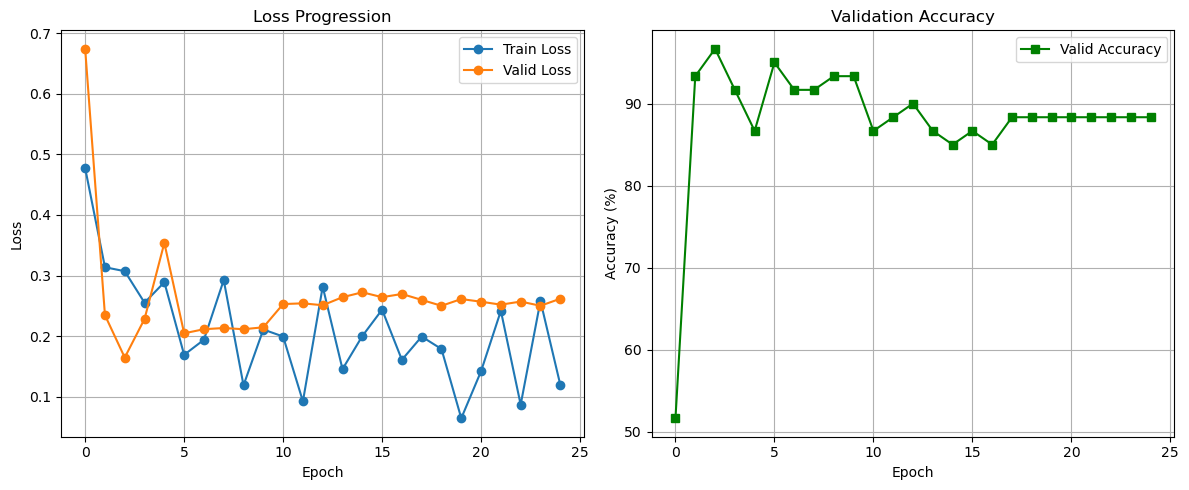

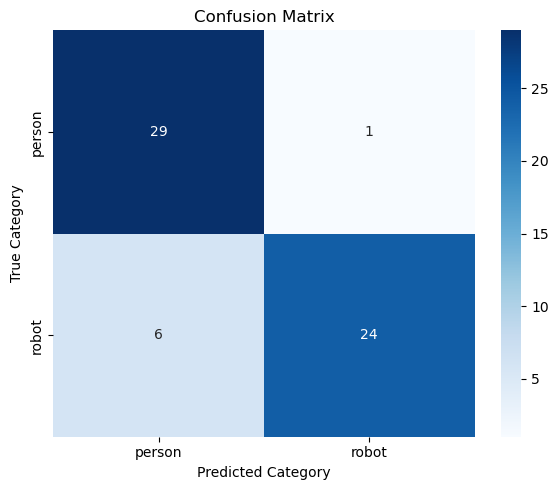

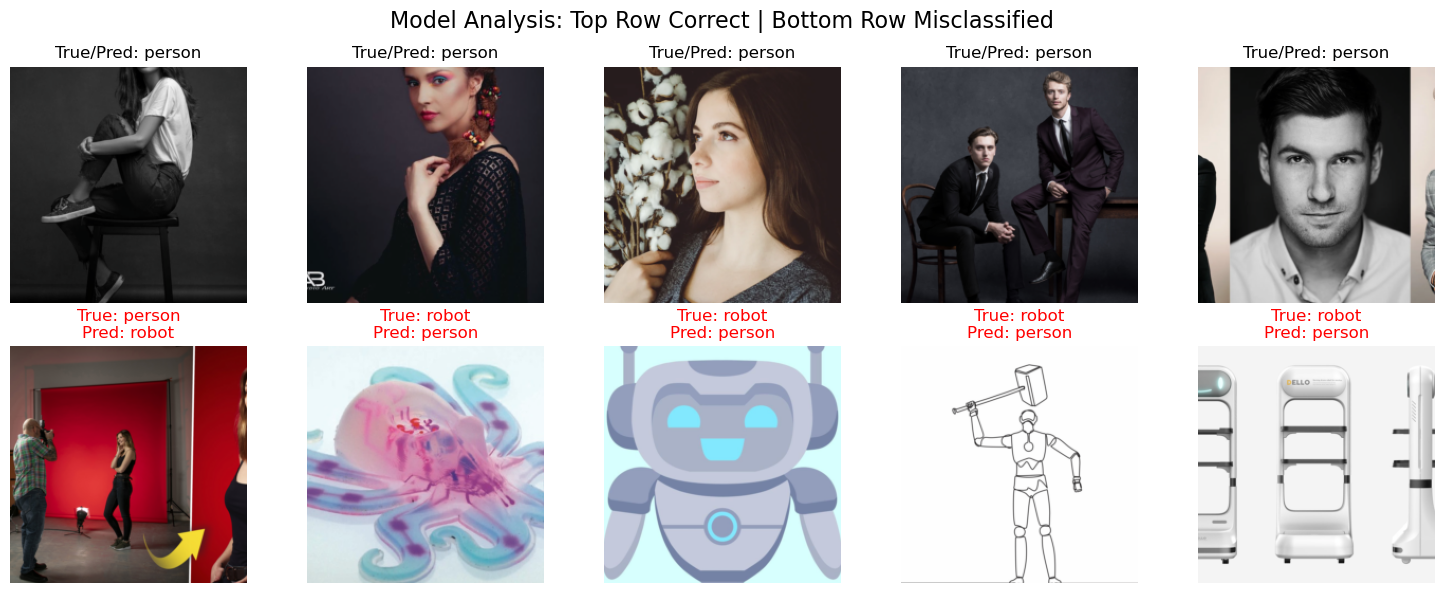

Diagnostics saved successfully as local images!


In [101]:
# resnet configuration

TBOARD_LOGS = os.path.join(os.getcwd(), "tboard_logs", "CNNs", "Resnet_fine_tuning")
if not os.path.exists(TBOARD_LOGS):
    os.makedirs(TBOARD_LOGS)

shutil.rmtree(TBOARD_LOGS)
writer = SummaryWriter(TBOARD_LOGS)

# Training and optimization
set_random_seed()

# downloading pretrained model
model = models.resnet18(pretrained=True)  # https://github.com/pytorch/vision/blob/master/torchvision/models/resnet.py

# replacing classification head with a single linear layer that outputs 2 logits
num_logits = model.fc.in_features
model.fc = nn.Sequential(
        nn.Linear(num_logits, 512),  # Maps from ResNet's 512 features to your hidden 512
        nn.ReLU(),
        nn.Dropout(0.2),              # Drops 20% of activations to combat overfitting
        nn.Linear(512, 2)   # Final projection layer out to your 2 logits
    )

model = model.to(device)


# classification loss function
criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Decay LR by a factor of 3 every 5 epochs
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=1/3) # used same config as tutorial


train_loss, val_loss, loss_iters, valid_acc = train_model(
        model=model, optimizer=optimizer, scheduler=scheduler, criterion=criterion,
        train_loader=train_loader, valid_loader=valid_loader, num_epochs=25, tboard=writer, device=device
    )

print("\nGenerating final visualization plots...")
    
# Plot loss curves and accuracy over time
plot_training_progress(train_loss, val_loss, valid_acc)

# Generate confusion matrix and show sample images
# Using valid_loader ensures you don't evaluate on CutMix/MixUp distorted samples
generate_diagnostics(model, valid_loader, device, class_names=['person', 'robot'])

print("Diagnostics saved successfully as local images!")